# ДЗ1: VSSD

VSSD на CIFAR-10 против Tiny-ViT и ResNet-18.

## Конфиг

In [1]:
import torch
import torchvision

device = torch.device("cuda" if torch.cuda.is_available() else "mps")

print("PyTorch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("Device:", device)

PyTorch: 2.11.0+cu128
torchvision: 0.26.0+cu128
Device: cuda


## Данные - CIFAR-10

10 классов, 32×32, 50k/10k.

In [2]:
import numpy as np
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from datasets import load_dataset

mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ConvertImageDtype(torch.float),
    transforms.Normalize(mean, std),
])
test_tf = transforms.Compose([
    transforms.ConvertImageDtype(torch.float),
    transforms.Normalize(mean, std),
])

cifar = load_dataset("uoft-cs/cifar10")
classes = cifar["train"].features["label"].names


def load_split(split):
    rows = cifar[split]
    imgs = np.stack([np.array(im.convert("RGB")) for im in rows["img"]])
    imgs = torch.from_numpy(imgs).permute(0, 3, 1, 2).contiguous()
    return imgs, torch.tensor(rows["label"])


class Cifar(Dataset):
    def __init__(self, imgs, labels, tf):
        self.imgs, self.labels, self.tf = imgs, labels, tf

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return self.tf(self.imgs[i]), self.labels[i]


train_set = Cifar(*load_split("train"), train_tf)
test_set = Cifar(*load_split("test"), test_tf)

batch_size = 128
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Train: {len(train_set)}  Test: {len(test_set)}  Classes: {len(classes)}")
print(classes)

Train: 50000  Test: 10000  Classes: 10
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## VSSD

NC-SSD: in_proj в z/x/B/C/dt, mixer KV=Kᵀ·(V·w), выход Q·KV.

In [3]:
import time
import torch.nn as nn
import torch.nn.functional as F


def count_params(model):
    return sum(p.numel() for p in model.parameters())


class DropPath(nn.Module):
    def __init__(self, p):
        super().__init__()
        self.p = p

    def forward(self, x):
        if self.p == 0 or not self.training:
            return x
        keep = 1 - self.p
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        mask = torch.rand(shape, dtype=x.dtype, device=x.device) + keep
        return x / keep * mask.floor()


class NCSSD(nn.Module):
    def __init__(self, dim, d_state=64, expand=2, headdim=32, d_conv=3):
        super().__init__()
        self.d_inner = expand * dim
        self.headdim = headdim
        self.nheads = self.d_inner // headdim
        self.d_state = d_state
        self.in_proj = nn.Linear(dim, 2 * self.d_inner + 2 * d_state + self.nheads)
        self.conv2d = nn.Conv2d(self.d_inner, self.d_inner, d_conv, padding=d_conv // 2, groups=self.d_inner)
        self.A_log = nn.Parameter(torch.zeros(self.nheads))
        self.D = nn.Parameter(torch.ones(self.nheads))
        self.dt_bias = nn.Parameter(torch.zeros(self.nheads))
        self.norm = nn.LayerNorm(self.d_inner)
        self.out_proj = nn.Linear(self.d_inner, dim)

    def forward(self, x, H, W):
        B, L, _ = x.shape
        z, xc, Bk, Ck, dt = torch.split(
            self.in_proj(x),
            [self.d_inner, self.d_inner, self.d_state, self.d_state, self.nheads],
            dim=-1,
        )
        xc = self.conv2d(xc.transpose(1, 2).reshape(B, self.d_inner, H, W))
        xc = F.silu(xc.flatten(2).transpose(1, 2))
        V = xc.reshape(B, L, self.nheads, self.headdim).permute(0, 2, 1, 3)
        A = -torch.exp(self.A_log)
        dt = F.softplus(dt + self.dt_bias)
        w = dt.permute(0, 2, 1).unsqueeze(-1) * (-A).view(1, -1, 1, 1)
        Q = Ck.reshape(B, 1, L, self.d_state)
        K = Bk.reshape(B, 1, L, self.d_state)
        KV = K.transpose(-2, -1) @ (V * w)
        y = Q @ KV + V * self.D.view(1, -1, 1, 1)
        y = y.permute(0, 2, 1, 3).reshape(B, L, self.d_inner)
        y = self.norm(y) * F.silu(z)
        return self.out_proj(y)


class VSSDBlock(nn.Module):
    def __init__(self, dim, d_state=64, expand=2, headdim=32, mlp_ratio=2.0, drop_path=0.0):
        super().__init__()
        self.cpe1 = nn.Conv2d(dim, dim, 3, padding=1, groups=dim)
        self.norm1 = nn.LayerNorm(dim)
        self.mixer = NCSSD(dim, d_state, expand, headdim)
        self.cpe2 = nn.Conv2d(dim, dim, 3, padding=1, groups=dim)
        self.norm2 = nn.LayerNorm(dim)
        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(dim, hidden), nn.GELU(), nn.Linear(hidden, dim))
        self.drop_path = DropPath(drop_path)

    def _conv(self, conv, x, H, W):
        B, L, C = x.shape
        return conv(x.transpose(1, 2).reshape(B, C, H, W)).flatten(2).transpose(1, 2)

    def forward(self, x, H, W):
        x = x + self._conv(self.cpe1, x, H, W)
        x = x + self.drop_path(self.mixer(self.norm1(x), H, W))
        x = x + self._conv(self.cpe2, x, H, W)
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x


class PatchEmbed(nn.Module):
    def __init__(self, in_ch=3, dim=96, patch=4):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, dim, patch, stride=patch)
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        x = self.proj(x)
        H, W = x.shape[2], x.shape[3]
        x = x.flatten(2).transpose(1, 2)
        return self.norm(x), H, W


class Downsample(nn.Module):
    def __init__(self, dim, out_dim):
        super().__init__()
        self.conv = nn.Conv2d(dim, out_dim, 3, stride=2, padding=1)
        self.norm = nn.LayerNorm(out_dim)

    def forward(self, x, H, W):
        B, L, C = x.shape
        x = self.conv(x.transpose(1, 2).reshape(B, C, H, W))
        H, W = x.shape[2], x.shape[3]
        x = x.flatten(2).transpose(1, 2)
        return self.norm(x), H, W


class VSSD(nn.Module):
    def __init__(self, num_classes=10, patch=4, dims=(96, 192, 384), depths=(2, 4, 2),
                 d_state=64, expand=2, headdim=32, mlp_ratio=2.0, drop_path=0.1):
        super().__init__()
        self.patch_embed = PatchEmbed(3, dims[0], patch)
        dpr = torch.linspace(0, drop_path, sum(depths)).tolist()
        self.stages = nn.ModuleList()
        self.downsamples = nn.ModuleList()
        k = 0
        for i, (dim, depth) in enumerate(zip(dims, depths)):
            self.stages.append(nn.ModuleList(
                [VSSDBlock(dim, d_state, expand, headdim, mlp_ratio, dpr[k + j]) for j in range(depth)]
            ))
            k += depth
            if i < len(dims) - 1:
                self.downsamples.append(Downsample(dim, dims[i + 1]))
        self.norm = nn.LayerNorm(dims[-1])
        self.head = nn.Linear(dims[-1], num_classes)

    def forward(self, x):
        x, H, W = self.patch_embed(x)
        for i, blocks in enumerate(self.stages):
            for blk in blocks:
                x = blk(x, H, W)
            if i < len(self.downsamples):
                x, H, W = self.downsamples[i](x, H, W)
        return self.head(self.norm(x).mean(dim=1))

In [4]:
model = VSSD()
out = model(torch.randn(2, 3, 32, 32))
print("output:", out.shape, "| params:", f"{count_params(model) / 1e6:.2f}M")

output: torch.Size([2, 10]) | params: 5.80M


## Аналоги

- Tiny-ViT: та же токенизация, patch 4 даёт 64 токена, mixer attention - 2.4M
- ResNet-18 с CIFAR-stem свёрточный baseline - 11.2M.

In [5]:
from torchvision.models import resnet18


class ViTBlock(nn.Module):
    def __init__(self, dim, heads, mlp_ratio=2.0, drop_path=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(dim, hidden), nn.GELU(), nn.Linear(hidden, dim))
        self.drop_path = DropPath(drop_path)

    def forward(self, x):
        h = self.norm1(x)
        x = x + self.drop_path(self.attn(h, h, h, need_weights=False)[0])
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x


class TinyViT(nn.Module):
    def __init__(self, num_classes=10, patch=4, img_size=32, dim=192, depth=8, heads=6,
                 mlp_ratio=2.0, drop_path=0.1):
        super().__init__()
        self.patch_embed = nn.Conv2d(3, dim, patch, stride=patch)
        n = (img_size // patch) ** 2
        self.cls = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos = nn.Parameter(torch.zeros(1, n + 1, dim))
        dpr = torch.linspace(0, drop_path, depth).tolist()
        self.blocks = nn.ModuleList([ViTBlock(dim, heads, mlp_ratio, dpr[i]) for i in range(depth)])
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, num_classes)
        nn.init.trunc_normal_(self.pos, std=0.02)
        nn.init.trunc_normal_(self.cls, std=0.02)

    def forward(self, x):
        x = self.patch_embed(x).flatten(2).transpose(1, 2)
        x = torch.cat([self.cls.expand(x.shape[0], -1, -1), x], dim=1) + self.pos
        for blk in self.blocks:
            x = blk(x)
        return self.head(self.norm(x)[:, 0])


def resnet18_cifar(num_classes=10):
    m = resnet18(num_classes=num_classes)
    m.conv1 = nn.Conv2d(3, 64, 3, stride=1, padding=1, bias=False)
    m.maxpool = nn.Identity()
    return m

## Обучение

AdamW, cosine, label smoothing, bf16

In [6]:
import random
import numpy as np


def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    crit = nn.CrossEntropyLoss()
    loss_sum, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        with torch.autocast(device_type=device.type, dtype=torch.bfloat16):
            out = model(x)
            loss = crit(out, y)
        loss_sum += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += x.size(0)
    return loss_sum / total, correct / total


def train_model(model, epochs=40, lr=1e-3, weight_decay=0.05):
    model.to(device)
    crit = nn.CrossEntropyLoss(label_smoothing=0.1)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    hist = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": [], "time": []}
    for epoch in range(epochs):
        model.train()
        t0 = time.time()
        loss_sum, correct, total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            with torch.autocast(device_type=device.type, dtype=torch.bfloat16):
                out = model(x)
                loss = crit(out, y)
            loss.backward()
            opt.step()
            loss_sum += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
        sched.step()
        tr_loss, tr_acc = loss_sum / total, correct / total
        te_loss, te_acc = evaluate(model, test_loader)
        dt = time.time() - t0
        for key, val in zip(hist, [tr_loss, tr_acc, te_loss, te_acc, dt]):
            hist[key].append(val)
        print(f"epoch {epoch + 1:2d}/{epochs}  train {tr_acc:.4f}  test {te_acc:.4f}  {dt:.1f}s")
    return hist

In [7]:
set_seed(0)
models = {
    "VSSD": VSSD(),
    "TinyViT": TinyViT(),
    "ResNet18": resnet18_cifar(),
}
for name, m in models.items():
    print(f"{name:<10} {count_params(m) / 1e6:.2f}M")

VSSD       5.80M
TinyViT    2.40M
ResNet18   11.17M


In [8]:
histories = {}
for name, m in models.items():
    print(f"\n=== {name} ===")
    set_seed(0)
    histories[name] = train_model(m, epochs=40)


=== VSSD ===
epoch  1/40  train 0.4088  test 0.5081  38.0s
epoch  2/40  train 0.5339  test 0.6056  20.8s
epoch  3/40  train 0.6023  test 0.6468  19.1s
epoch  4/40  train 0.6592  test 0.6954  20.6s
epoch  5/40  train 0.6969  test 0.7199  20.9s
epoch  6/40  train 0.7311  test 0.7431  20.9s
epoch  7/40  train 0.7528  test 0.7644  19.4s
epoch  8/40  train 0.7706  test 0.7662  21.1s
epoch  9/40  train 0.7870  test 0.7839  20.6s
epoch 10/40  train 0.7985  test 0.7966  20.7s
epoch 11/40  train 0.8137  test 0.7990  20.0s
epoch 12/40  train 0.8221  test 0.8064  19.9s
epoch 13/40  train 0.8252  test 0.8018  18.6s
epoch 14/40  train 0.8281  test 0.8128  18.7s
epoch 15/40  train 0.8159  test 0.7794  19.4s
epoch 16/40  train 0.8298  test 0.8159  18.6s
epoch 17/40  train 0.8452  test 0.7959  17.2s
epoch 18/40  train 0.8390  test 0.8199  17.3s
epoch 19/40  train 0.8457  test 0.8134  18.0s
epoch 20/40  train 0.8511  test 0.8204  17.8s
epoch 21/40  train 0.8624  test 0.8335  17.1s
epoch 22/40  train 0

## Результаты

In [9]:
print(f"{'Model':<10}{'Params, M':>12}{'Best acc':>12}{'Final acc':>12}{'s/epoch':>12}")
for name, m in models.items():
    h = histories[name]
    spe = sum(h["time"]) / len(h["time"])
    print(f"{name:<10}{count_params(m) / 1e6:>12.2f}{max(h['test_acc']):>12.4f}{h['test_acc'][-1]:>12.4f}{spe:>12.1f}")

Model        Params, M    Best acc   Final acc     s/epoch
VSSD              5.80      0.8563      0.8558        19.3
TinyViT           2.40      0.7644      0.7644        13.8
ResNet18         11.17      0.9374      0.9374        12.4


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
panels = [("train_loss", "train loss"), ("test_loss", "test loss"),
          ("train_acc", "train acc"), ("test_acc", "test acc")]
for ax, (key, title) in zip(axes.flat, panels):
    for name, h in histories.items():
        ax.plot(h[key], label=name)
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

: 

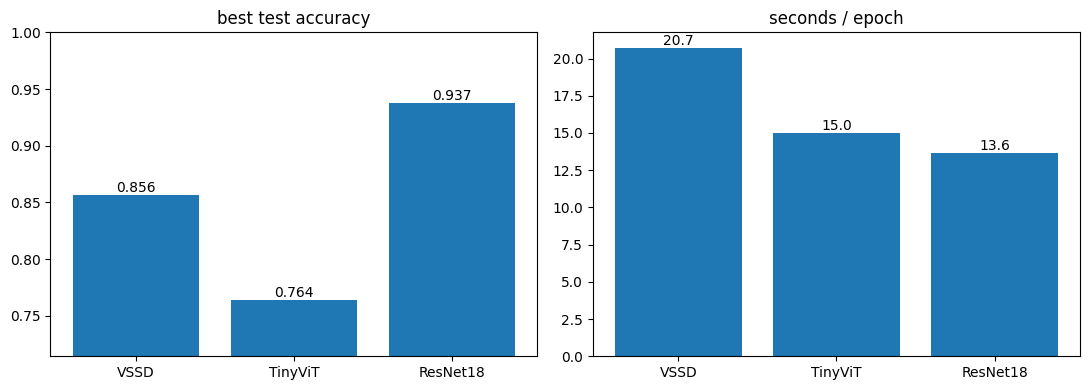

In [ ]:
names = list(histories)
best_acc = [max(histories[n]["test_acc"]) for n in names]
spe = [sum(histories[n]["time"]) / len(histories[n]["time"]) for n in names]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.bar(names, best_acc)
ax1.set_title("best test accuracy")
ax1.set_ylim(min(best_acc) - 0.05, 1.0)
for i, v in enumerate(best_acc):
    ax1.text(i, v, f"{v:.3f}", ha="center", va="bottom")
ax2.bar(names, spe)
ax2.set_title("seconds / epoch")
for i, v in enumerate(spe):
    ax2.text(i, v, f"{v:.1f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

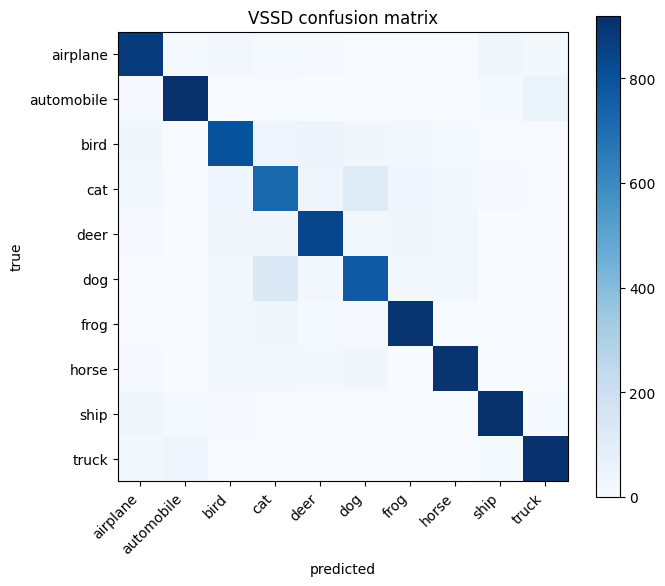

In [ ]:
from sklearn.metrics import confusion_matrix

vssd = models["VSSD"].to(device)
vssd.eval()
preds, targets = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        with torch.autocast(device_type=device.type, dtype=torch.bfloat16):
            out = vssd(x)
        preds.append(out.argmax(1).cpu())
        targets.append(y)
preds = torch.cat(preds).numpy()
targets = torch.cat(targets).numpy()

cm = confusion_matrix(targets, preds)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10), classes, rotation=45, ha="right")
ax.set_yticks(range(10), classes)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("VSSD confusion matrix")
plt.colorbar(im)
plt.tight_layout()
plt.show()

## Выводы

40 эпох, CIFAR-10
| Модель | Params | Best acc | s/epoch |
|--------|--------|----------|---------|
| VSSD | 5.80M | 0.856 | 19.3 |
| TinyViT | 2.40M | 0.764 | 13.8 |
| ResNet18 | 11.17M | 0.937 | 12.4 |

ResNet18 лучший, но и больше по параметра. VSSD выше TinyViT, но у него в 2.4 раза больше параметров. VSSD самый медленный: на 64 токенах линейность NC-SSD не нужна, а CPE+conv в каждом блоке дорогие. На 32×32 метод не даёт скорости, выигрыша в точности.